## Imports and Reading Results

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [102]:
adv_block_path = Path('../results/adversarial_blocking')
save_dir = Path('../results/adversarial_blocking')

In [103]:
models = list(adv_block_path.iterdir())
models

[PosixPath('../results/adversarial_blocking/resnet18_nosampling.pdf'),
 PosixPath('../results/adversarial_blocking/resnet18_normalized_nosampling.pdf'),
 PosixPath('../results/adversarial_blocking/mobilenet_v3_large_normalized_nosampling'),
 PosixPath('../results/adversarial_blocking/mobilenet_v3_large_normalized_nosampling.pdf'),
 PosixPath('../results/adversarial_blocking/resnet18_nosampling_adv'),
 PosixPath('../results/adversarial_blocking/resnet18_normalized_nosampling_adv'),
 PosixPath('../results/adversarial_blocking/resnet18_nosampling'),
 PosixPath('../results/adversarial_blocking/resnet18_normalized_nosampling'),
 PosixPath('../results/adversarial_blocking/resnet18_normalized_nosampling_adv.pdf')]

In [112]:
import json

model_results = {}

for model in models:
    model_name = model.name
    results = model/'results.json'
    if not results.exists():
        continue
    with open(results) as fp:
        results = json.load(fp)
    model_results[model_name]=results
        

In [115]:
model_results

{'mobilenet_v3_large_normalized_nosampling': {'no_attack': {'f1_score': 0.9639418125152588,
   'blocked_f1_score': 0.4160230755805969,
   'mse_loss': 0.0006402666331268847,
   'confusion_matrix': [[128, 0, 0, 0, 38, 0, 0, 0, 0],
    [0, 598, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 665, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 170, 0, 0, 0, 0, 0],
    [60, 0, 0, 2, 3471, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 173, 0, 0, 0],
    [0, 0, 0, 0, 2, 0, 1438, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1403, 37],
    [0, 0, 0, 0, 0, 0, 0, 0, 1440]],
   'blocked_confusion_matrix': [[147, 0, 1, 5, 13, 0, 0, 0, 0],
    [0, 598, 0, 0, 0, 0, 0, 0, 0],
    [0, 361, 304, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 170, 0, 0, 0, 0, 0],
    [1287, 0, 89, 513, 1601, 2, 0, 0, 43],
    [9, 0, 0, 0, 133, 31, 0, 0, 0],
    [1, 0, 0, 30, 136, 0, 207, 0, 1066],
    [18, 0, 0, 4, 96, 0, 0, 135, 1187],
    [1, 0, 0, 8, 38, 0, 0, 0, 1393]]},
  'FastGradientMethod_eps_0.0001': {'f1_score': 0.9104052782058716,
   'blocked_f1_score': 0.4156450033187866,
   

In [105]:
import pandas as pd

all_results = []

for model, results in model_results.items():
    for atk_type, result in results.items():
        if atk_type!='no_attack':
            eps = atk_type.split('eps_')[-1]
            atk_name =  atk_type.split('eps_')[0]
            atk_name = 'FGSM' if 'Fast' in atk_name else 'BIGM'
            eps=float(eps)
        else:
            eps = 0
            atk_name = 'NA'
        f1 = result['f1_score']
        blocked_f1 = result['blocked_f1_score']
        mse_loss = result['mse_loss']
        all_results.append([model, atk_name, eps, f1, blocked_f1, mse_loss])

res_df = pd.DataFrame(all_results, columns=['model','atk', 'eps', 'f1', 'blocked_f1','mse'])
res_df
    

,model,atk,eps,f1,blocked_f1,mse
0,mobilenet_v3_large_normalized_nosampling,NA,0.0000,0.963942,0.416023,0.000640
1,mobilenet_v3_large_normalized_nosampling,FGSM,0.0001,0.910405,0.415645,0.000641
2,mobilenet_v3_large_normalized_nosampling,FGSM,0.0010,0.360729,0.411204,0.000643
3,mobilenet_v3_large_normalized_nosampling,FGSM,0.0100,0.317456,0.405659,0.000653
4,mobilenet_v3_large_normalized_nosampling,FGSM,0.1000,0.058972,0.227177,0.000714
5,mobilenet_v3_large_normalized_nosampling,BIGM,0.0001,0.897192,0.415720,0.000641
6,mobilenet_v3_large_normalized_nosampling,BIGM,0.0010,0.062080,0.411625,0.000642
7,mobilenet_v3_large_normalized_nosampling,BIGM,0.0100,0.020248,0.415548,0.000650
8,mobilenet_v3_large_normalized_nosampling,BIGM,0.1000,0.001857,0.274971,0.000695
9,resnet18_nosampling_adv,NA,0.0000,0.921701,0.812616,0.019462


In [106]:
df = res_df.copy()


In [107]:
df.model.unique()

array(['mobilenet_v3_large_normalized_nosampling',
       'resnet18_nosampling_adv', 'resnet18_normalized_nosampling_adv',
       'resnet18_nosampling', 'resnet18_normalized_nosampling'],
      dtype=object)

In [108]:
def plot_groupped_bars(df:pd.DataFrame, save_as:Path,title:str='F1 and Blocked F1'): 
    
    groups = ['No Attack', 'ε=0.0001', 'ε=0.001', 'ε=0.01', 'ε=0.1']
    
    # Plot style
    sns.set_theme(style="whitegrid", font="serif", rc={
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    for ax, attack in zip(axes, ['FGSM', 'BIGM']):
        records = []
        # Baseline
        base = df[df['atk']=='NA'].iloc[0]
        records += [
            {'group': 'No Attack', 'metric': 'F1',         'score': base['f1']},
            {'group': 'No Attack', 'metric': 'Blocked F1','score': base['blocked_f1']}
        ]
        # Adversarial groups
        for eps in [0.0001, 0.001, 0.01, 0.1]:
            row = df[(df['atk']==attack)&(df['eps']==eps)].iloc[0]
            label = f'ε={eps}'
            records += [
                {'group': label, 'metric': 'F1',         'score': row['f1']},
                {'group': label, 'metric': 'Blocked F1','score': row['blocked_f1']}
            ]
        plot_df = pd.DataFrame.from_records(records)
    
        sns.barplot(
            data=plot_df,
            x='group',
            y='score',
            hue='metric',
            ax=ax,
            palette=['#2E86AB', '#A0C5E8'],
            edgecolor='black'
        )
        ax.set_title(f'{attack} Attack')
        ax.set_xlabel('')
        if ax is axes[0]:
            ax.set_ylabel('Score')
        else:
            ax.set_ylabel('')
        ax.set_ylim(0, 1.0)
        ax.set_yticks([i/10 for i in range(0, 11)])
        ax.grid(axis='y', linestyle='--', color='gray', alpha=0.5)
    
        # Annotate
        for p in ax.patches:
            h = p.get_height()
            # Only annotate if height is meaningful
            if h < 0.01:
                continue
            ax.annotate(f'{h:.2f}',
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=10)
        ax.legend(title='Metric')
    
    # Final touches
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_as, dpi=300)
    plt.show()



mobilenet_v3_large_normalized_nosampling


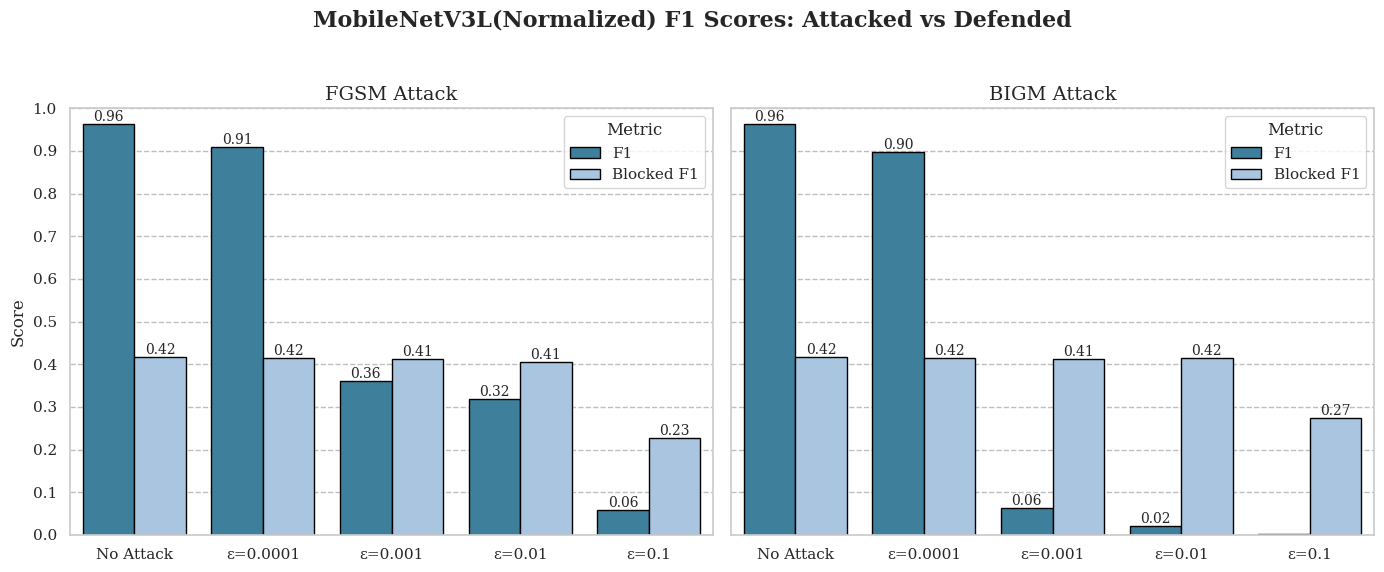

resnet18_nosampling_adv


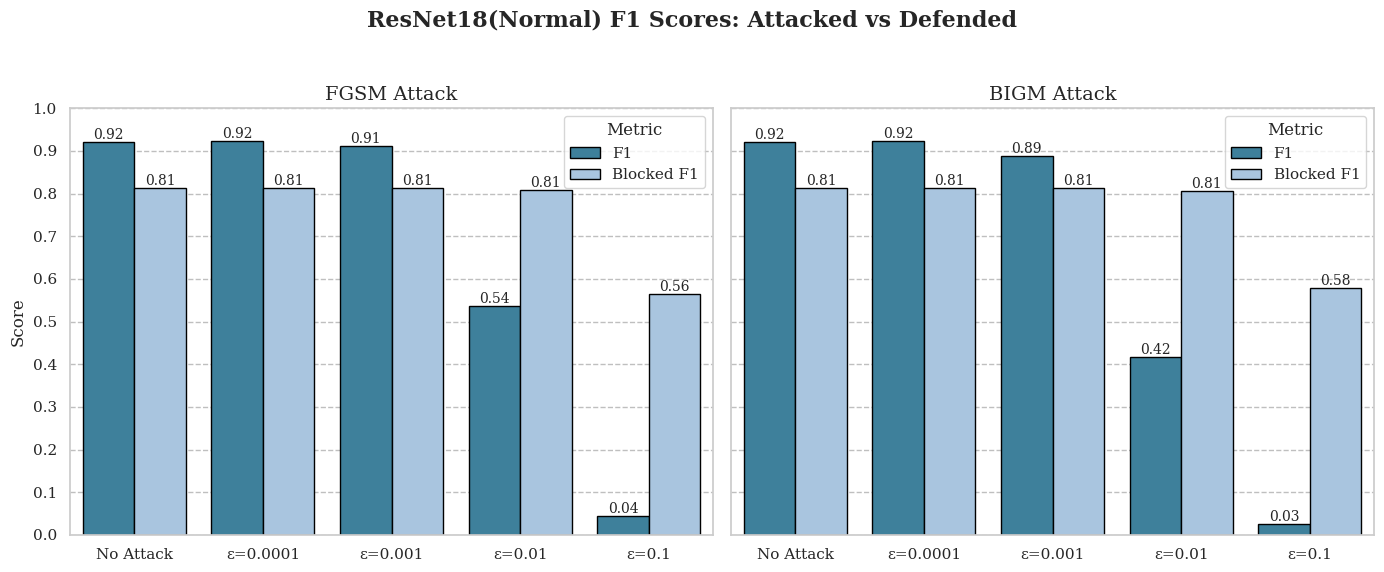

resnet18_normalized_nosampling_adv


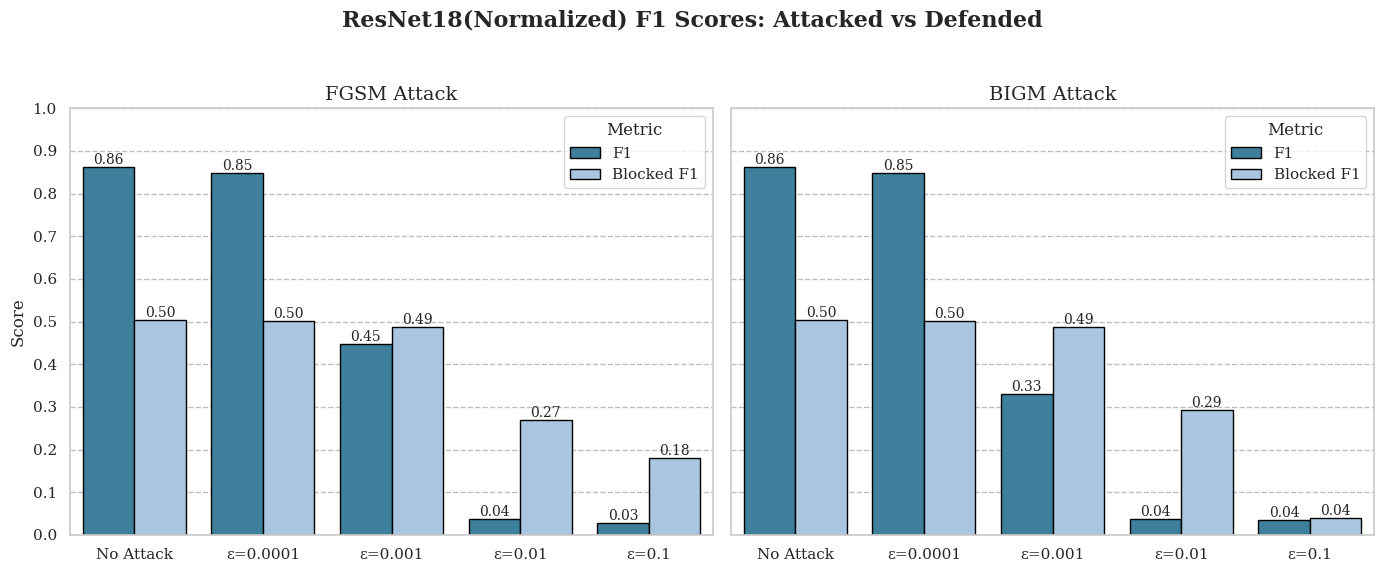

resnet18_nosampling


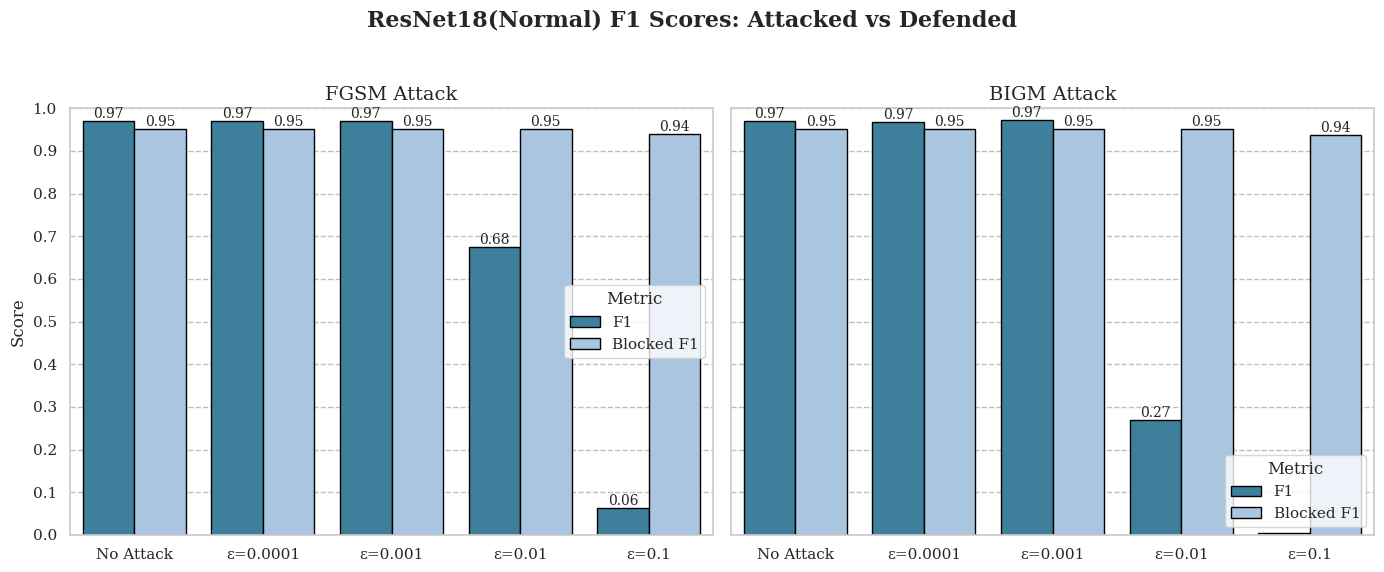

resnet18_normalized_nosampling


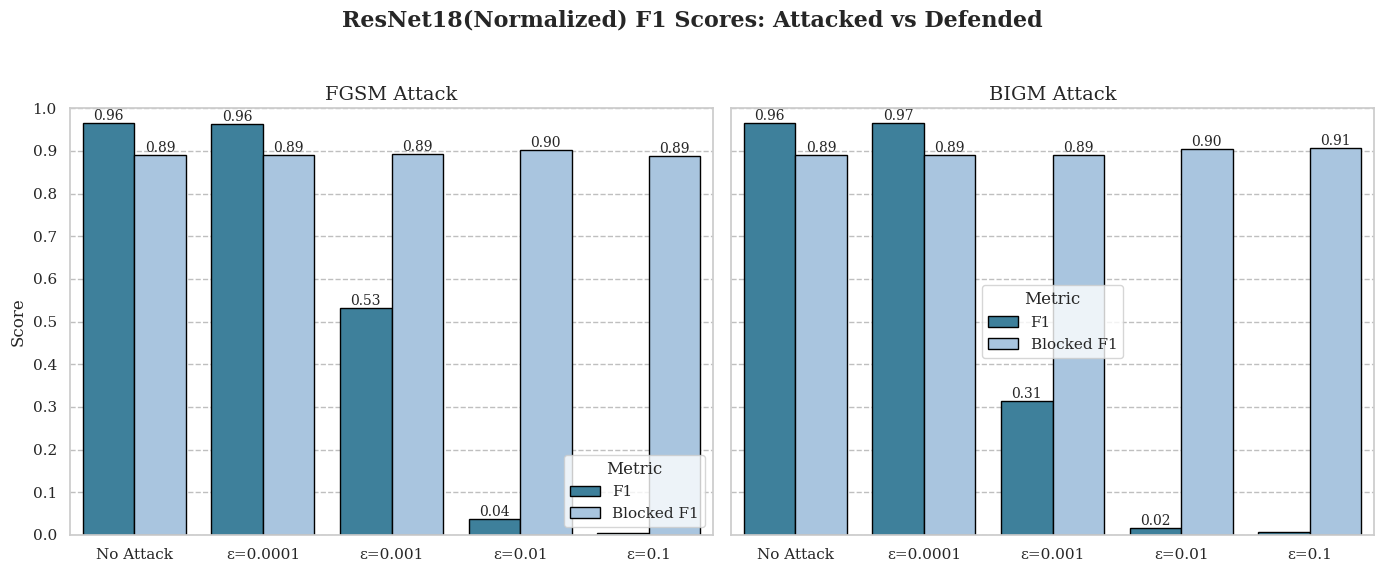

In [109]:
for model_name in df.model.unique():
    print(model_name)
    ndf = df.query('model==@model_name')
    backbone = 'ResNet18' if 'resnet' in model_name else 'MobileNetV3L'
    data_type = 'Normalized' if 'normalized' in model_name.lower() else 'Normal'
    title_name = f'{backbone}({data_type})'
    plot_groupped_bars(ndf, title=f'{title_name} F1 Scores: Attacked vs Defended',save_as=save_dir/f'{model_name}.pdf')